<a href="https://colab.research.google.com/github/Gayatri230/Bangalore-House-Price-Prediction/blob/main/project7XGB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/sample_data/online_retail.csv.zip')

In [ ]:
df.head(15)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [ ]:
df = df.dropna(subset=['CustomerID'])

In [ ]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [ ]:
purchase_counts = df.groupby('CustomerID')['InvoiceNo'].unique()

In [ ]:
df['RepeatPurchase'] = (
    df.groupby('CustomerID')['InvoiceNo']
      .transform('nunique')
      .gt(1)
      .astype(int)
)

In [ ]:
customer_df = df.groupby('CustomerID').agg({
    'InvoiceNo': 'nunique',
    'Quantity': 'sum',
    'UnitPrice': 'mean',
    'Country': 'first',
    'RepeatPurchase': 'max'}).reset_index()

In [ ]:
customer_df.rename(columns={
    'InvoiceNo': 'Frequency',
    'Quantity': 'TotalQuantity',
    'UnitPrice': 'AvgUnitPrice'
}, inplace=True)

In [ ]:
customer_df.head()

,CustomerID,Frequency,TotalQuantity,AvgUnitPrice,Country,RepeatPurchase
0,12346.0,1,74215,1.040000,United Kingdom,0
1,12347.0,7,2458,2.644011,Iceland,1
2,12348.0,4,2341,5.764839,Finland,1
3,12349.0,1,631,8.289041,Italy,0
4,12350.0,1,197,3.841176,Norway,0


In [ ]:
customer_df = pd.get_dummies(customer_df, columns=['Country'], drop_first=True)

In [ ]:
customer_df.columns

Index(['CustomerID', 'Frequency', 'TotalQuantity', 'AvgUnitPrice',
       'RepeatPurchase', 'Country_Austria', 'Country_Bahrain',
       'Country_Belgium', 'Country_Brazil', 'Country_Canada',
       'Country_Channel Islands', 'Country_Cyprus', 'Country_Czech Republic',
       'Country_Denmark', 'Country_EIRE', 'Country_European Community',
       'Country_Finland', 'Country_France', 'Country_Germany',
       'Country_Greece', 'Country_Iceland', 'Country_Israel', 'Country_Italy',
       'Country_Japan', 'Country_Lebanon', 'Country_Lithuania',
       'Country_Malta', 'Country_Netherlands', 'Country_Norway',
       'Country_Poland', 'Country_Portugal', 'Country_RSA',
       'Country_Saudi Arabia', 'Country_Singapore', 'Country_Spain',
       'Country_Sweden', 'Country_Switzerland', 'Country_USA',
       'Country_United Arab Emirates', 'Country_United Kingdom',
       'Country_Unspecified'],
      dtype='object')

In [60]:
x = customer_df.drop(['RepeatPurchase', 'Frequency'], axis=1)
y = customer_df['RepeatPurchase']

In [61]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [73]:
from xgboost import XGBClassifier
model = XGBClassifier(n_estimators=200, max_depth=5,random_state=42,eval_metric='logloss')
model.fit(x_train, y_train)
predictions = model.predict(x_test)


In [74]:
from sklearn.metrics import accuracy_score

accuracy_score = accuracy_score(y_test, predictions)

print("Accuracy Score:", accuracy_score)

Accuracy Score: 0.8248847926267281


In [64]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))

[[193  98]
 [ 53 524]]
              precision    recall  f1-score   support

           0       0.78      0.66      0.72       291
           1       0.84      0.91      0.87       577

    accuracy                           0.83       868
   macro avg       0.81      0.79      0.80       868
weighted avg       0.82      0.83      0.82       868



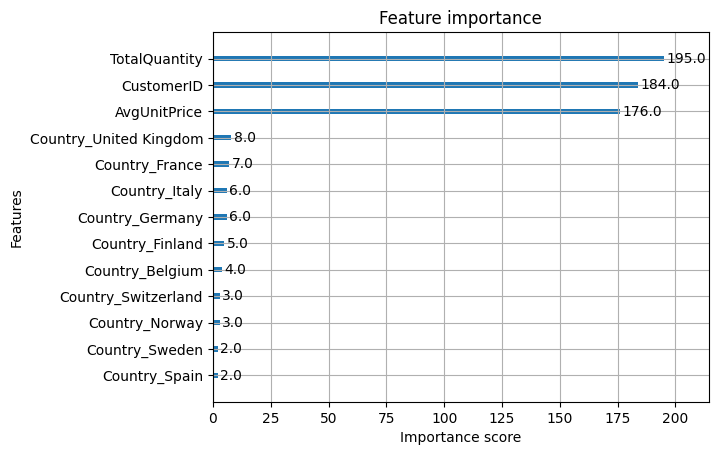

In [65]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(model)
plt.show()